# Step 6 — Monte Carlo simulation of the 2026 World Cup

**Goal:** turn match probabilities into tournament probabilities: each team's chance of getting out of the group, reaching each round and winning the trophy.

**Monte Carlo idea:** we can't calculate every possible tournament path directly, because there are far too many. Instead we **play the whole tournament thousands of times** with random draws weighted by the model's probabilities, and count how often each thing happens. If Spain win in 1,200 of 10,000 simulated tournaments, their estimated chance is 12%.

**The test is retrospective:** the models only use information from **before** the tournament started. At the end we compare the forecast with what actually happened.

## 1. Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

# Save everything in Google Drive, so each notebook can use the previous notebook's outputs.
# Colab will ask for permission to access your Drive the first time.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/world-cup-prediction"
except ImportError:          # running on your own computer instead of Colab
    BASE = "."
os.makedirs(BASE, exist_ok=True)
os.chdir(BASE)
for folder in ["data", "models", "preds"]:
    os.makedirs(folder, exist_ok=True)
print("Working folder:", os.getcwd())

Mounted at /content/drive
Working folder: /content/drive/MyDrive/world-cup-prediction


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
START_YEAR = 1990

def load_matches():
    """Load cleaned matches (downloading and cleaning them first if needed)."""
    path = "data/matches_clean.csv"
    if not os.path.exists(path):
        raw = pd.read_csv(URL, parse_dates=["date"])
        df = raw.dropna(subset=["home_score", "away_score"])
        df = df[df["date"].dt.year >= START_YEAR].copy()
        df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.sort_values(["date", "home_team", "away_team"], kind="stable").reset_index(drop=True)
    df["match_id"] = df.index
    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    df["neutral"] = df["neutral"].astype(bool)
    # Result coded as a class: 0 = home win, 1 = draw, 2 = away win
    df["result"] = np.select([df["home_score"] > df["away_score"],
                              df["home_score"] < df["away_score"]], [0, 2], default=1)
    return df

def add_splits(df):
    """train: before 2024 | val: 2024 until the World Cup | test: the 2026 World Cup matches."""
    wc26 = (df["tournament"] == "FIFA World Cup") & (df["date"].dt.year == 2026)
    test_start = df.loc[wc26, "date"].min() if wc26.any() else pd.Timestamp("2026-06-11")
    val_start = pd.Timestamp("2024-01-01")
    df["split"] = np.select([df["date"] < val_start, df["date"] < test_start, wc26],
                            ["train", "val", "test"], default="after")
    return df, val_start, test_start

matches, VAL_START, TEST_START = add_splits(load_matches())
print(matches["split"].value_counts().to_string())
print("Validation starts:", VAL_START.date(), "| Test (World Cup 2026) starts:", TEST_START.date())

split
train    29787
val       2564
after      366
test       104
Validation starts: 2024-01-01 | Test (World Cup 2026) starts: 2026-06-11


In [3]:
needed = ["models/elo_ratings_wc2026.csv", "models/elo_wdl.joblib", "models/elo_config.json",
          "models/dc_params_test.json", "models/nn_model.pt", "models/nn_scaler.joblib",
          "models/nn_features.json", "models/team_snapshot_wc2026.csv", "models/ensemble_weights.json"]
missing = [f for f in needed if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Run notebooks 02–05 first. Missing: {missing}")

## 2. Rebuild the groups from the data

The dataset doesn't store group letters, so we work them out: in the group stage, each team plays the other three teams in its group. If we connect every pair of teams that played each other, the 12 groups appear as 12 separate clusters of 4 teams.

*(Our group numbers follow the order of the first match, so they may not match FIFA's official letters.)*

In [4]:
wc = matches[matches["split"] == "test"].sort_values(["date", "match_id"])
if len(wc) < 72:
    raise ValueError("The 2026 World Cup group stage isn't fully in the data yet.")
group_stage = wc.iloc[:72]

# Union-find: link teams that played each other
parent = {}
def find(t):
    parent.setdefault(t, t)
    while parent[t] != t:
        parent[t] = parent[parent[t]]
        t = parent[t]
    return t
for r in group_stage.itertuples():
    parent[find(r.home_team)] = find(r.away_team)

clusters = {}
for team in pd.unique(group_stage[["home_team", "away_team"]].values.ravel()):
    clusters.setdefault(find(team), []).append(team)
GROUPS = sorted(clusters.values(), key=lambda g: group_stage.index[
    group_stage["home_team"].isin(g) | group_stage["away_team"].isin(g)].min())
assert len(GROUPS) == 12 and all(len(g) == 4 for g in GROUPS), "Unexpected group structure"
TEAMS = [t for g in GROUPS for t in g]
for i, g in enumerate(GROUPS, 1):
    print(f"Group {i:>2}: {', '.join(g)}")

Group  1: Mexico, South Africa, South Korea, Czech Republic
Group  2: Canada, Bosnia and Herzegovina, Qatar, Switzerland
Group  3: United States, Paraguay, Australia, Turkey
Group  4: Brazil, Morocco, Haiti, Scotland
Group  5: Germany, Curaçao, Ivory Coast, Ecuador
Group  6: Netherlands, Japan, Sweden, Tunisia
Group  7: Belgium, Egypt, Iran, New Zealand
Group  8: Saudi Arabia, Uruguay, Spain, Cape Verde
Group  9: Argentina, Algeria, Austria, Jordan
Group 10: France, Senegal, Iraq, Norway
Group 11: England, Croatia, Ghana, Panama
Group 12: Portugal, DR Congo, Uzbekistan, Colombia


## 3. Match probabilities for every possible pairing

We load the three models and compute the ensemble probability for every pair of the 48 teams once, so the simulation itself is fast.

- The three **host nations** (United States, Mexico, Canada) get home advantage; every other match is treated as neutral.
- **Dixon-Coles** also gives a full scoreline distribution, which we use to generate realistic scores (goal difference matters for group tie-breaks).

In [5]:
import joblib
import torch
from torch import nn
from scipy.stats import poisson

HOSTS = {"United States", "Mexico", "Canada"}

# --- Elo ---
elo_ratings = pd.read_csv("models/elo_ratings_wc2026.csv").set_index("team")["elo"]
elo_model = joblib.load("models/elo_wdl.joblib")
HOME_ADV = json.load(open("models/elo_config.json"))["home_adv"]

# --- Dixon-Coles ---
dc = json.load(open("models/dc_params_test.json"))
dc_idx = {t: i for i, t in enumerate(dc["teams"])}

def dc_matrix(home, away, neutral, max_goals=10):
    get = lambda key, team: dc[key][dc_idx[team]] if team in dc_idx else 0.0
    lam = np.exp(dc["intercept"] + (0 if neutral else dc["home"]) + get("att", home) + get("def", away))
    mu = np.exp(dc["intercept"] + get("att", away) + get("def", home))
    g = np.arange(max_goals + 1)
    M = np.outer(poisson.pmf(g, lam), poisson.pmf(g, mu))
    r = dc["rho"]
    M[0, 0] *= 1 - lam * mu * r; M[0, 1] *= 1 + lam * r; M[1, 0] *= 1 + mu * r; M[1, 1] *= 1 - r
    return M / M.sum()

# --- Neural network (same architecture as Step 4) ---
FEATURES = json.load(open("models/nn_features.json"))
scaler = joblib.load("models/nn_scaler.joblib")
snapshot = pd.read_csv("models/team_snapshot_wc2026.csv").set_index("team")
net = nn.Sequential(nn.Linear(len(FEATURES), 32), nn.ReLU(), nn.Dropout(0.2),
                    nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 3))
net.load_state_dict(torch.load("models/nn_model.pt"))
net.eval()

WEIGHTS = json.load(open("models/ensemble_weights.json"))
print("Ensemble weights:", WEIGHTS)

Ensemble weights: {'elo': 0.05, 'dc': 0.55, 'nn': 0.4}


In [6]:
def oriented(a, b):
    """Who is 'home'? A host nation plays at home; otherwise the venue is neutral."""
    if b in HOSTS and a not in HOSTS:
        return b, a, False, True        # home, away, neutral, flipped
    return a, b, not (a in HOSTS), False

pairs = [(a, b) for a in TEAMS for b in TEAMS if a != b]
rows, meta = [], []
for a, b in pairs:
    home, away, neutral, flipped = oriented(a, b)
    he, ae = elo_ratings.get(home, 1500), elo_ratings.get(away, 1500)
    feats = {"elo_diff": he - ae + (0 if neutral else HOME_ADV), "home_elo": he, "away_elo": ae,
             "is_neutral": float(neutral), "importance": 1.0}
    for side, team in [("home", home), ("away", away)]:
        for col in ["form_pts", "form_gf", "form_ga", "games_played"]:
            feats[f"{side}_{col}"] = snapshot.at[team, col] if team in snapshot.index else snapshot[col].mean()
    rows.append(feats)
    meta.append((home, away, neutral, flipped))
X = pd.DataFrame(rows)[FEATURES]

p_elo = elo_model.predict_proba((X["elo_diff"].values / 100).reshape(-1, 1))
with torch.no_grad():
    p_nn = torch.softmax(net(torch.tensor(scaler.transform(X), dtype=torch.float32)), dim=1).numpy()

PAIR = {}
for k, ((a, b), (home, away, neutral, flipped)) in enumerate(zip(pairs, meta)):
    Mx = dc_matrix(home, away, neutral)
    p_dc = np.array([np.tril(Mx, -1).sum(), np.trace(Mx), np.triu(Mx, 1).sum()])
    p = WEIGHTS["elo"] * p_elo[k] + WEIGHTS["dc"] * p_dc + WEIGHTS["nn"] * p_nn[k]
    if flipped:                     # turn everything back to a's point of view
        p, Mx = p[::-1], Mx.T
    # Scoreline distributions conditional on each outcome (rows = a's goals)
    masks = [np.tril(np.ones_like(Mx), -1), np.eye(len(Mx)), np.triu(np.ones_like(Mx), 1)]
    cond = [(Mx * m).ravel() / (Mx * m).sum() for m in masks]
    PAIR[(a, b)] = (p / p.sum(), cond, len(Mx))
print(f"Pre-computed {len(PAIR):,} pairings")

Pre-computed 2,256 pairings


## 4. The simulation

**Group stage:** every team plays its three group opponents. For each match we draw the outcome from the ensemble probabilities, then a scoreline consistent with that outcome. Teams are ranked by points, then goal difference, then goals scored.

**Who qualifies:** the top 2 in each group plus the 8 best third-placed teams make the **Round of 32**.

**Knockouts:** a drawn knockout match goes to penalties, which we treat as a 50/50 coin flip.

**A simplification to be aware of:** FIFA uses a fixed bracket that decides who meets whom. To keep the code short, we seed the 12 group winners and the 4 best runners-up, and draw their opponents at random. This slightly changes paths, but it hardly affects the overall picture.

In [7]:
rng = np.random.default_rng(42)
STAGES = ["Round of 32", "Round of 16", "Quarter-final", "Semi-final", "Final", "Champion"]

def play(a, b):
    """Returns (outcome from a's view: 0 win / 1 draw / 2 loss, a goals, b goals)."""
    p, cond, size = PAIR[(a, b)]
    outcome = rng.choice(3, p=p)
    cell = rng.choice(size * size, p=cond[outcome])
    return outcome, cell // size, cell % size

def play_knockout(a, b):
    outcome = rng.choice(3, p=PAIR[(a, b)][0])
    if outcome == 1:                                   # penalties
        return a if rng.random() < 0.5 else b
    return a if outcome == 0 else b

def rank_key(s):
    return (s["pts"], s["gd"], s["gf"], rng.random())

def simulate_once(counts):
    winners, runners, thirds = [], [], []
    for group in GROUPS:
        table = {t: {"team": t, "pts": 0, "gd": 0, "gf": 0} for t in group}
        for i in range(4):
            for j in range(i + 1, 4):
                a, b = group[i], group[j]
                outcome, ga, gb = play(a, b)
                table[a]["gf"] += ga; table[b]["gf"] += gb
                table[a]["gd"] += ga - gb; table[b]["gd"] += gb - ga
                table[a]["pts"] += [3, 1, 0][outcome]; table[b]["pts"] += [0, 1, 3][outcome]
        ranked = sorted(table.values(), key=rank_key, reverse=True)
        winners.append(ranked[0]); runners.append(ranked[1]); thirds.append(ranked[2])

    runners = sorted(runners, key=rank_key, reverse=True)
    best_thirds = sorted(thirds, key=rank_key, reverse=True)[:8]
    seeds = [s["team"] for s in winners + runners[:4]]
    others = [s["team"] for s in runners[4:] + best_thirds]
    rng.shuffle(others)

    alive = []
    for s, o in zip(seeds, others):
        alive += [s, o]
    for stage in STAGES[:-1]:
        for t in alive:
            counts[t][stage] += 1
        if len(alive) == 2:
            counts[play_knockout(*alive)]["Champion"] += 1
            break
        alive = [play_knockout(alive[k], alive[k + 1]) for k in range(0, len(alive), 2)]

In [8]:
N_SIMS = 5000          # more simulations = smoother estimates, but slower
counts = {t: {s: 0 for s in STAGES} for t in TEAMS}
for _ in range(N_SIMS):
    simulate_once(counts)

forecast = (pd.DataFrame(counts).T / N_SIMS * 100).round(1)
forecast = forecast.sort_values(["Champion", "Final", "Semi-final"], ascending=False)
forecast.head(20)

,Round of 32,Round of 16,Quarter-final,Semi-final,Final,Champion
Spain,99.2,75.0,55.1,38.4,25.9,16.3
Argentina,97.9,73.9,51.7,35.1,24.1,15.5
Brazil,96.7,66.5,45.2,28.4,15.2,8.2
England,97.3,64.7,40.2,20.8,12.7,7.0
France,93.3,61.3,33.1,19.1,10.7,5.7
Colombia,91.0,58.3,32.5,17.4,9.6,4.9
Mexico,94.8,58.2,35.4,19.5,9.8,4.5
Portugal,91.1,58.1,33.2,16.7,8.7,4.2
Morocco,90.8,52.7,30.4,16.4,7.4,3.6
Germany,95.8,56.9,31.2,15.4,7.3,3.0


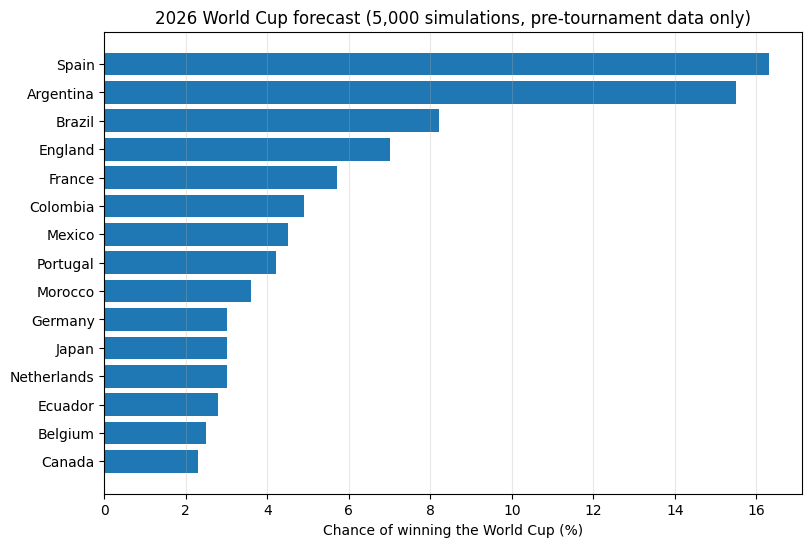

In [9]:
top = forecast.head(15)["Champion"][::-1]
plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values)
plt.xlabel("Chance of winning the World Cup (%)")
plt.title(f"2026 World Cup forecast ({N_SIMS:,} simulations, pre-tournament data only)")
plt.grid(axis="x", alpha=0.3); plt.show()

## 5. Reality check: how did the forecast do?

We compare the forecast with what actually happened: who reached the Round of 32, and who won the trophy.

In [10]:
knockout = wc.iloc[72:]
actual_r32 = set(knockout["home_team"]) | set(knockout["away_team"])
if actual_r32:
    predicted_r32 = set(forecast.nlargest(32, "Round of 32").index)
    print(f"Round of 32: the forecast's 32 most likely qualifiers included "
          f"{len(actual_r32 & predicted_r32)} of the {len(actual_r32)} actual qualifiers.")

final = wc.iloc[-1]
champion = None
if len(wc) == 104:
    if final["home_score"] != final["away_score"]:
        champion = final["home_team"] if final["home_score"] > final["away_score"] else final["away_team"]
    else:   # decided on penalties: check the shootouts file in the same dataset
        try:
            so = pd.read_csv(URL.replace("results.csv", "shootouts.csv"), parse_dates=["date"])
            hit = so[(so["date"] == final["date"]) & (so["home_team"] == final["home_team"])]
            champion = hit["winner"].iloc[0] if len(hit) else None
        except Exception:
            champion = None

if champion:
    rank = list(forecast.index).index(champion) + 1
    print(f"Actual champion: {champion} — the model gave them {forecast.at[champion, 'Champion']}% "
          f"(ranked #{rank} of 48 before the tournament).")
else:
    print(f"Final: {final['home_team']} {final['home_score']}-{final['away_score']} {final['away_team']}"
          " — check who won if it went to penalties.")

Round of 32: the forecast's 32 most likely qualifiers included 26 of the 32 actual qualifiers.
Actual champion: Spain — the model gave them 16.3% (ranked #1 of 48 before the tournament).
